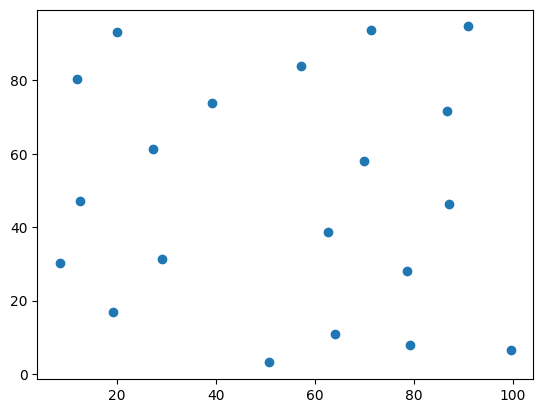

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import random, time

# --- Step 1: Generate 20 random points with min distance > 10 ---
num_points = 20
min_dist = 15
min_points = 3    # per driver
num_routes = 3

def generate_points(n, min_dist):
    points = []
    while len(points) < n:
        candidate = np.random.rand(2) * 100  # random in [0,100]x[0,100]
        if all(np.linalg.norm(candidate - p) > min_dist for p in points):
            points.append(candidate)
    return np.array(points)

points = generate_points(num_points, min_dist)
plt.scatter(points[:,0],points[:,1])

In [32]:
# --- Distance functions ---
def distance(a, b):
    return np.linalg.norm(points[a] - points[b])

def route_cost(route):
    if len(route) <= 1:
        return 0
    return sum(distance(route[i], route[(i+1)%len(route)]) for i in range(len(route)))

# --- Decode chromosome into 3 routes using split indices ---
def split_routes(chromosome, min_points=5):
    """
    chromosome = [perm..., split1, split2]
    Guarantees all drivers get >= min_points
    """
    perm = chromosome[:-2]
    # Ensure split1 < split2
    split1, split2 = min(chromosome[-2:], key=lambda x: x), max(chromosome[-2:], key=lambda x: x)
    
    # Compute feasible ranges for splits
    remaining = num_points - min_points * num_routes  # extra points to distribute
    max_split1 = min_points + remaining  # first split max
    split1 = max(min_points, min(split1, max_split1))
    
    min_split2 = split1 + min_points
    max_split2 = num_points - min_points
    split2 = max(min_split2, min(split2, max_split2))
    
    r1 = perm[:split1]
    r2 = perm[split1:split2]
    r3 = perm[split2:]
    
    return [list(r1), list(r2), list(r3)]

def total_cost(chromosome):
    routes = split_routes(chromosome)
    return sum(route_cost(r) for r in routes)



In [33]:
# === GA functions ===
# --- Initialize a random chromosome ---
def random_chromosome():
    perm = list(range(num_points))
    random.shuffle(perm)
    split1 = random.randint(1, num_points-2)
    split2 = random.randint(split1+1, num_points-1)
    return perm + [split1, split2]

def crossover(parent1, parent2):
    # crossover permutation
    a, b = sorted(random.sample(range(num_points), 2))
    child_perm = [-1]*num_points
    child_perm[a:b] = parent1[:][a:b]
    fill = [gene for gene in parent2[:num_points] if gene not in child_perm]
    idx = 0
    for i in range(num_points):
        if child_perm[i] == -1:
            child_perm[i] = fill[idx]
            idx += 1
    # crossover split indices
    split1 = random.choice([parent1[-2], parent2[-2]])
    split2 = random.choice([parent1[-1], parent2[-1]])
    return child_perm + [split1, split2]

def mutate(chrom, min_points=5):
    # swap two points in permutation
    i, j = random.sample(range(num_points), 2)
    chrom[i], chrom[j] = chrom[j], chrom[i]

    # mutate splits randomly
    remaining = num_points - min_points * num_routes
    chrom[-2] = max(min_points, min(chrom[-2] + random.choice([-1,0,1]), min_points + remaining))
    chrom[-1] = max(chrom[-2] + min_points, min(chrom[-1] + random.choice([-1,0,1]), num_points - min_points))

    return chrom


In [34]:
pop_size = 50
num_generations = 70
population = [random_chromosome() for _ in range(pop_size)]
best_costs = []

# --- GA loop ---
for gen in range(num_generations):
    population.sort(key=total_cost)
    best_cost = total_cost(population[0])
    best_costs.append(best_cost)
    print(f"Generation {gen+1}: Best cost = {best_cost:.2f}")

    new_pop = population[:10]  # elitism

    # Crossover: 32 children
    for _ in range(32):
        p1, p2 = random.sample(population[:25], 2)
        new_pop.append(crossover(p1, p2))

    # Mutation: 14 children
    for _ in range(14):
        p = random.choice(population[:20])
        new_pop.append(mutate(p.copy()))

    # New random: 4
    for _ in range(4):
        new_pop.append(random_chromosome())

    population = new_pop

# --- Results ---
best = min(population, key=total_cost)
best_routes = split_routes(best)

print("\n=== Best Routes ===")
for i, r in enumerate(best_routes):
    print(f"Driver {i+1}: {r}, cost = {route_cost(r):.2f}")
print(f"Total cost = {total_cost(best):.2f}")
print(f"Split indices = {best[-2:]}, lengths = {[len(r) for r in best_routes]}")

Generation 1: Best cost = 846.91
Generation 2: Best cost = 776.41
Generation 3: Best cost = 776.41
Generation 4: Best cost = 776.41
Generation 5: Best cost = 757.54
Generation 6: Best cost = 711.66
Generation 7: Best cost = 711.66
Generation 8: Best cost = 711.66
Generation 9: Best cost = 711.66
Generation 10: Best cost = 691.47
Generation 11: Best cost = 691.47
Generation 12: Best cost = 691.47
Generation 13: Best cost = 672.33
Generation 14: Best cost = 625.28
Generation 15: Best cost = 625.28
Generation 16: Best cost = 625.20
Generation 17: Best cost = 625.20
Generation 18: Best cost = 625.20
Generation 19: Best cost = 625.20
Generation 20: Best cost = 603.40
Generation 21: Best cost = 603.40
Generation 22: Best cost = 603.40
Generation 23: Best cost = 603.32
Generation 24: Best cost = 602.39
Generation 25: Best cost = 602.39
Generation 26: Best cost = 602.39
Generation 27: Best cost = 602.39
Generation 28: Best cost = 602.39
Generation 29: Best cost = 602.39
Generation 30: Best cos

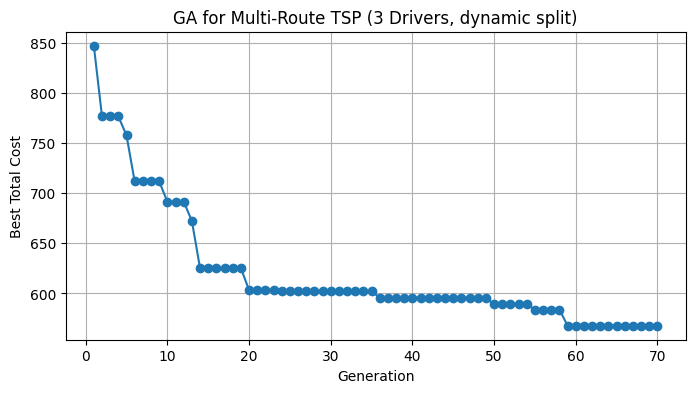

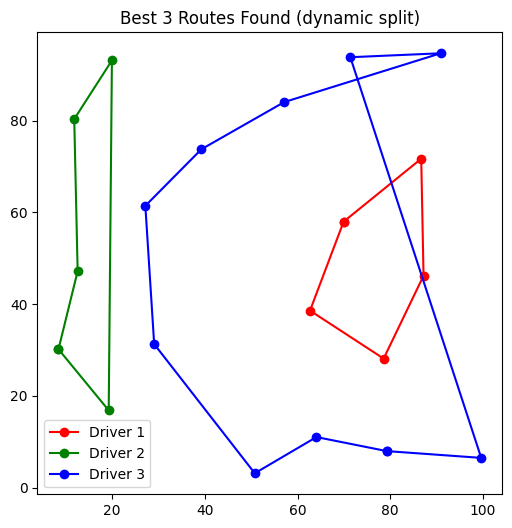

In [35]:
# --- Plot best cost over generations ---
plt.figure(figsize=(8,4))
plt.plot(range(1, num_generations+1), best_costs, marker='o')
plt.title("GA for Multi-Route TSP (3 Drivers, dynamic split)")
plt.xlabel("Generation")
plt.ylabel("Best Total Cost")
plt.grid(True)
plt.show()

# --- Visualize best routes ---
colors = ['r','g','b']
plt.figure(figsize=(6,6))
for i, route in enumerate(best_routes):
    route_points = np.array([points[j] for j in route + [route[0]]])
    plt.plot(route_points[:,0], route_points[:,1], '-o', color=colors[i], label=f"Driver {i+1}")
plt.title("Best 3 Routes Found (dynamic split)")
plt.legend()
plt.show()